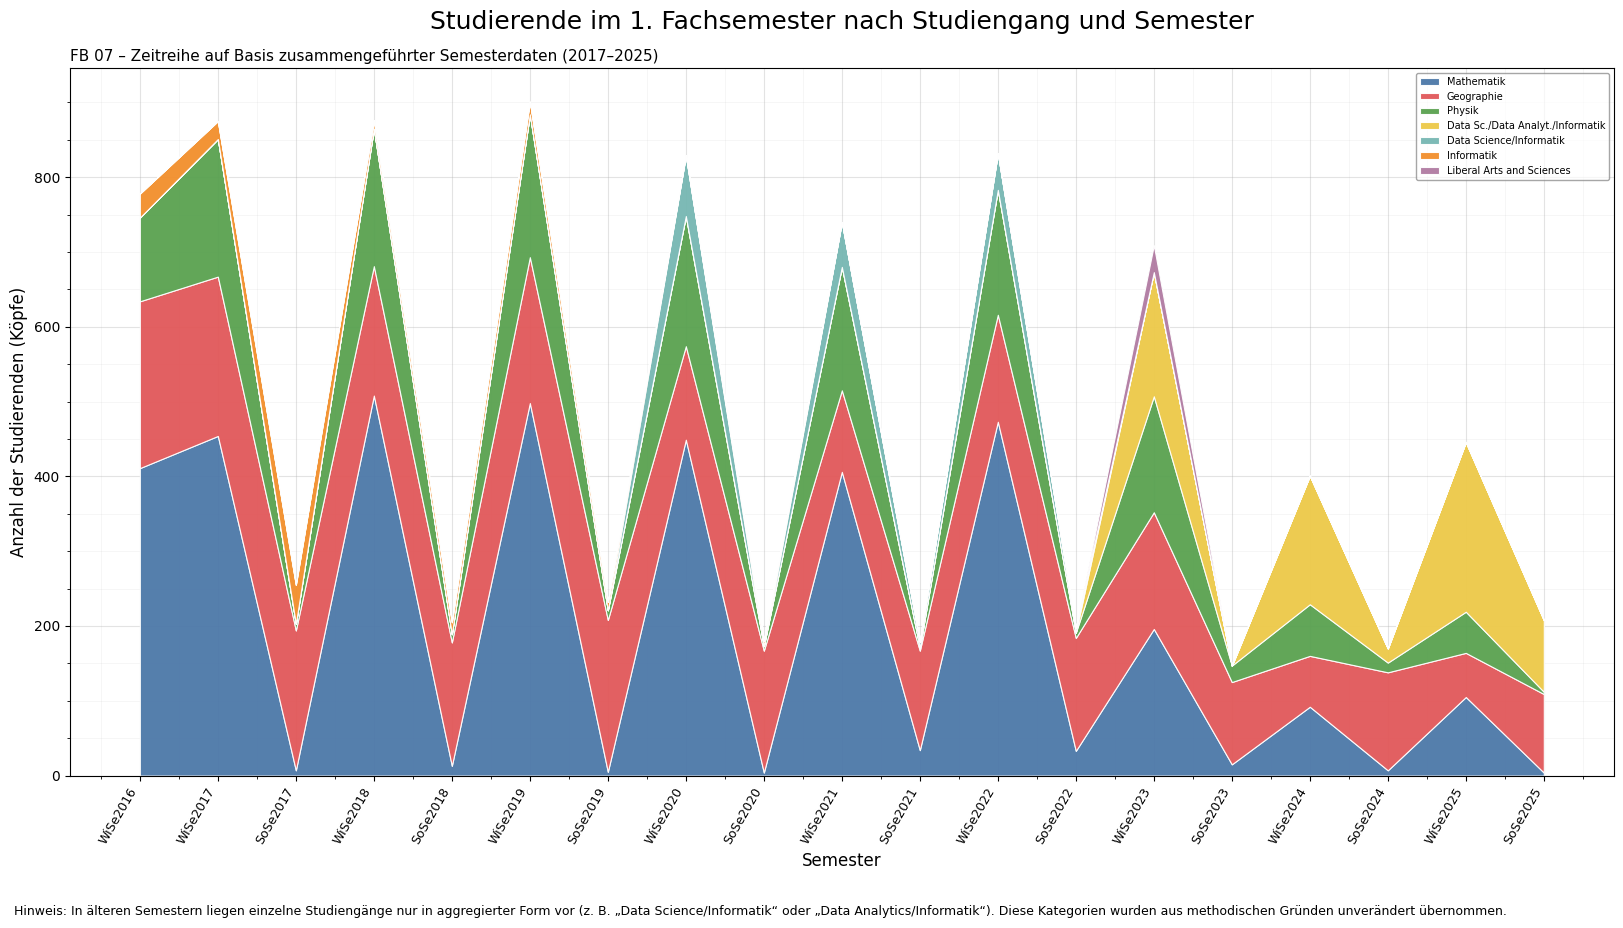

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# =========================
# 1) Daten laden
# =========================
dataset1 = pd.read_csv(
    r"C:\Users\Ich\Documents\Uni\Visualisierung\Projekt\data_excels\Studierende im 1. Fachsemester\Studierende im ersten Fachsemester.csv"
)
dataset2 = pd.read_csv(
    r"C:\Users\Ich\Documents\Uni\Visualisierung\Projekt\data_excels\wise24 - wise25\1_Fachsemester_Köpfe.csv"
)

dataset1 = dataset1[["Studienfach", "Summe_Koepfe", "Jahr", "Semester"]].copy()
dataset2 = dataset2[["Studienfach", "Summe_Koepfe", "Jahr", "Semester"]].copy()

# =========================
# 2) Schreibweisen harmonisieren
# =========================
dataset1["Studienfach"] = dataset1["Studienfach"].replace({
    "Geograph./Erdk.": "Geographie"
})

dataset2["Studienfach"] = dataset2["Studienfach"].replace({
    "mathematik": "Mathematik",
    "physik": "Physik",
    "geographie": "Geographie",
    "informatik": "Informatik",
    "data science": "Data Science",
    "data analytics": "Data Analytics"
})

dataset1["Jahr"] = dataset1["Jahr"].astype(int)
dataset2["Jahr"] = dataset2["Jahr"].astype(int)

# =========================
# 3) Überlappende Semester aus dataset1 entfernen
# =========================
mask_overlap = (
    ((dataset1["Jahr"] == 2024) & (dataset1["Semester"] == "Winter")) |
    ((dataset1["Jahr"] == 2025) & (dataset1["Semester"].isin(["Sommer", "Winter"])))
)
dataset1_clean = dataset1[~mask_overlap].copy()

# =========================
# 4) Neuere Daten logisch zusammenführen
# =========================
dataset2_step = dataset2.copy()

target_all_three = {
    (2024, "Winter"),
    (2025, "Sommer"),
    (2025, "Winter"),
}

mask_all_three = (
    dataset2_step["Studienfach"].isin(["Informatik", "Data Science", "Data Analytics"]) &
    dataset2_step[["Jahr", "Semester"]].apply(lambda r: (int(r["Jahr"]), r["Semester"]), axis=1).isin(target_all_three)
)

rows_all_three = dataset2_step[mask_all_three]
rows_keep = dataset2_step[~mask_all_three]

merged_all_three = (
    rows_all_three
    .groupby(["Jahr", "Semester"], as_index=False)["Summe_Koepfe"]
    .sum()
)
merged_all_three["Studienfach"] = "Data Sc./Data Analyt./Informatik"

dataset2_final = pd.concat([rows_keep, merged_all_three], ignore_index=True)

# =========================
# 5) Datensätze kombinieren
# =========================
df = pd.concat([dataset1_clean, dataset2_final], ignore_index=True).reset_index(drop=True)

desired_features = [
    "Data Sc./Data Analyt./Informatik",
    "Data Science/Informatik",
    "Geographie",
    "Informatik",
    "Liberal Arts and Sciences",
    "Mathematik",
    "Physik",
]

df = df[df["Studienfach"].isin(desired_features)].copy()

# =========================
# 6) Semesterfelder erzeugen
# =========================
semester_order = {"Winter": 0, "Sommer": 1}
semester_short = {"Winter": "WiSe", "Sommer": "SoSe"}

def add_semester_fields(dframe):
    dframe = dframe.copy()
    dframe["semester_sort"] = dframe["Semester"].map(semester_order)
    dframe["Semester_Label"] = dframe["Semester"].map(semester_short) + dframe["Jahr"].astype(str)
    dframe["x_order"] = dframe["Jahr"] * 10 + dframe["semester_sort"]
    return dframe

df = add_semester_fields(df)

# =========================
# 7) Pivot
# =========================
plot_df = df.pivot_table(
    index=["x_order", "Semester_Label"],
    columns="Studienfach",
    values="Summe_Koepfe",
    aggfunc="sum"
).reset_index().sort_values("x_order")

for feat in desired_features:
    if feat not in plot_df.columns:
        plot_df[feat] = 0

plot_df = plot_df[["x_order", "Semester_Label"] + desired_features]
plot_df[desired_features] = plot_df[desired_features].fillna(0)

# =========================
# 8) Reihenfolge der Flächen
# =========================
feature_sums = plot_df[desired_features].sum(axis=0).sort_values(ascending=False)
stack_order = feature_sums.index.tolist()

x = list(range(len(plot_df)))
x_labels = plot_df["Semester_Label"].tolist()

# =========================
# 9) Alte Farbpalette wiederherstellen
# =========================
color_map = {
    "Mathematik": "#4C78A8",
    "Physik": "#59A14F",
    "Informatik": "#F28E2B",
    "Geographie": "#E15759",
    "Liberal Arts and Sciences": "#B07AA1",
    "Data Science/Informatik": "#76B7B2",
    "Data Sc./Data Analyt./Informatik": "#EDC948",
}
colors = [color_map[col] for col in stack_order]

# =========================
# 10) Plot
# =========================
fig, ax = plt.subplots(figsize=(19, 10), facecolor="white")
ax.set_facecolor("white")

collections = ax.stackplot(
    x,
    *[plot_df[col].values for col in stack_order],
    labels=stack_order,
    colors=colors,
    alpha=0.95,
    linewidth=0.8,
    edgecolor="white"
)

ax.set_title(
    "Studierende im 1. Fachsemester nach Studiengang und Semester",
    fontsize=18,
    pad=28
)

ax.text(
    0,
    1.005,
    "FB 07 – Zeitreihe auf Basis zusammengeführter Semesterdaten (2017–2025)",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom"
)

ax.set_xlabel("Semester", fontsize=12)
ax.set_ylabel("Anzahl der Studierenden (Köpfe)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=60, ha="right", fontsize=9)
ax.tick_params(axis="y", labelsize=10)

ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(which="major", axis="both", linestyle="-", linewidth=0.8, alpha=0.35)
ax.grid(which="minor", axis="both", linestyle="-", linewidth=0.4, alpha=0.18)

legend_order = desired_features
handle_map = {label: coll for label, coll in zip(stack_order, collections)}
legend_handles = [handle_map[f] for f in legend_order if f in handle_map]
legend_labels = [f for f in legend_order if f in handle_map]

ax.legend(
    loc='upper right',        # Position dans le graphique
    fontsize=7,              # Texte plus petit
    ncol=1,                  # 1 colonnes pour compacter
    framealpha=0.7,          # Fond semi-transparent
    edgecolor='gray'
)

fig.text(
    0.01,
    0.01,
    "Hinweis: In älteren Semestern liegen einzelne Studiengänge nur in aggregierter Form vor "
    "(z. B. „Data Science/Informatik“ oder „Data Analytics/Informatik“). "
    "Diese Kategorien wurden aus methodischen Gründen unverändert übernommen.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 0.86, 0.93])
plt.show()